# Terrain Modifications: High-Ground Levee Writer

This notebook validates the ras-commander high-ground terrain modification writer with a real HEC-RAS example project. It creates a copied terrain sidecar modification, verifies the before/after terrain surface, runs HEC-RAS through `RasCmdr.compute_plan()`, and compares maximum water surface elevations.

## Workflow

1. Extract two copies of the BaldEagleCrkMulti2D example project.
2. Add a `take_higher` high-ground line modification to the proposed copy.
3. Verify the `.rasmap` registration and terrain HDF sidecar values.
4. Plot writer-computed and raster-read before/after terrain profiles.
5. Plot terrain difference at mesh cells.
6. Run base and proposed plan 18 with geometry preprocessing forced.
7. Compare maximum water surface elevations from the two result HDF files.

In [1]:
# Development-source setup and imports
from pathlib import Path
import logging
import shutil
import sys
import warnings
import xml.etree.ElementTree as ET

import h5py
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import numpy as np
import pandas as pd

candidates = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(path for path in candidates if (path / 'ras_commander').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ras_commander import HdfMesh, HdfResultsMesh, RasCmdr, RasExamples, init_ras_project
from ras_commander.terrain import RasTerrainMod, RasTerrainModification, RasTerrainModWriter

logging.getLogger('ras_commander').setLevel(logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.display.max_columns = 20

ARTIFACT_ROOT = Path('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications')
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Repository: {REPO_ROOT}')
print(f'Artifacts:  {ARTIFACT_ROOT}')

Repository: C:\GH\symphony-workspaces\ras-commander\CLB-279
Artifacts:  H:\Symphony\ras-commander\CLB-279\316_terrain_modifications


In [2]:
# Extract isolated base/proposed/polygon project copies
template = RasExamples.extract_project(
    'BaldEagleCrkMulti2D',
    output_path=ARTIFACT_ROOT,
    suffix='template',
)
base_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_base'
proposed_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_proposed'
polygon_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_polygon_multipoint'
for project in (base_project, proposed_project, polygon_project):
    if project.exists():
        shutil.rmtree(project)
    shutil.copytree(template, project)

base_ras = init_ras_project(base_project, '6.6', ras_object='new', load_results_summary=False)
proposed_ras = init_ras_project(proposed_project, '6.6', ras_object='new', load_results_summary=False)
polygon_ras = init_ras_project(polygon_project, '6.6', ras_object='new', load_results_summary=False)

plan_number = '18'
plan_row = base_ras.plan_df.loc[base_ras.plan_df['plan_number'] == plan_number].iloc[0]
geom_number = str(plan_row['Geom File'])
base_geom_hdf = Path(base_ras.geom_df.loc[base_ras.geom_df['geom_number'] == geom_number, 'hdf_path'].iloc[0])
proposed_geom_hdf = proposed_project / base_geom_hdf.name
polygon_geom_hdf = polygon_project / base_geom_hdf.name
terrain_value = proposed_ras.rasmap_df['terrain_hdf_path'].iloc[0]
proposed_terrain_hdf = Path(terrain_value[0] if isinstance(terrain_value, list) else terrain_value)
polygon_terrain_value = polygon_ras.rasmap_df['terrain_hdf_path'].iloc[0]
polygon_terrain_hdf = Path(
    polygon_terrain_value[0]
    if isinstance(polygon_terrain_value, list)
    else polygon_terrain_value
)

summary = pd.DataFrame([
    {'condition': 'base', 'project': str(base_project), 'geom_hdf': str(base_geom_hdf)},
    {'condition': 'high-ground proposed', 'project': str(proposed_project), 'terrain_hdf': str(proposed_terrain_hdf)},
    {'condition': 'polygon proposed', 'project': str(polygon_project), 'terrain_hdf': str(polygon_terrain_hdf)},
])
summary

,condition,project,geom_hdf,terrain_hdf
0,base,H:\Symphony\ras-commander\CLB-279\316_terrain_...,I:\Symphony\ras-commander\CLB-279\316_terrain_...,NaN
1,high-ground proposed,H:\Symphony\ras-commander\CLB-279\316_terrain_...,NaN,I:\Symphony\ras-commander\CLB-279\316_terrain_...
2,polygon proposed,H:\Symphony\ras-commander\CLB-279\316_terrain_...,NaN,I:\Symphony\ras-commander\CLB-279\316_terrain_...


In [3]:
# Define a levee/road alignment across the BaldEagleCr 2D flow area
mesh_areas = HdfMesh.get_mesh_areas(base_geom_hdf)
target_area = mesh_areas.loc[mesh_areas['mesh_name'] == 'BaldEagleCr'].iloc[0]
minx, miny, maxx, maxy = target_area.geometry.bounds
line_y = miny + 0.55 * (maxy - miny)
profile_x = [minx + 0.15 * (maxx - minx), maxx - 0.15 * (maxx - minx)]
profile_y = [line_y, line_y]

RasTerrainMod.setup_gdal_bridge('6.6')
baseline_profile = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=10.0,
)
profile_points = baseline_profile[['station', 'elevation']].to_numpy(dtype=float).copy()
profile_points[:, 1] += 20.0
mod_line = np.array([[profile_x[0], profile_y[0]], [profile_x[1], profile_y[1]]], dtype=float)

RasTerrainModWriter.add_high_ground_modification(
    terrain_hdf_path=proposed_terrain_hdf,
    rasmap_path=proposed_project / 'BaldEagleDamBrk.rasmap',
    name='API High Ground Levee',
    polyline_points=mod_line,
    profile_points=profile_points,
    top_width=120.0,
    side_slope=4.0,
    max_extent=600.0,
    elev_pt_tolerance=20.0,
)

mods = RasTerrainModWriter.list_modifications(proposed_terrain_hdf)
rasmap_text = (proposed_project / 'BaldEagleDamBrk.rasmap').read_text(encoding='utf-8')
print('Modification registered in .rasmap:', 'API High Ground Levee' in rasmap_text)
mods

Modification registered in .rasmap: True


,name,type,subtype,priority,modification_type,modification_mode,width,left_slope,right_slope,max_extent,elev_pt_tolerance,profile_points
0,API High Ground Levee,Levee,Levee,0,1,take_higher,120.0,4.0,4.0,600.0,20.0,108


,terrain_difference_ft
count,108.000000
mean,20.000001
std,0.000006
min,20.000000
25%,20.000000
50%,20.000000
75%,20.000000
max,20.000061


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/terrain_profile_difference.png')

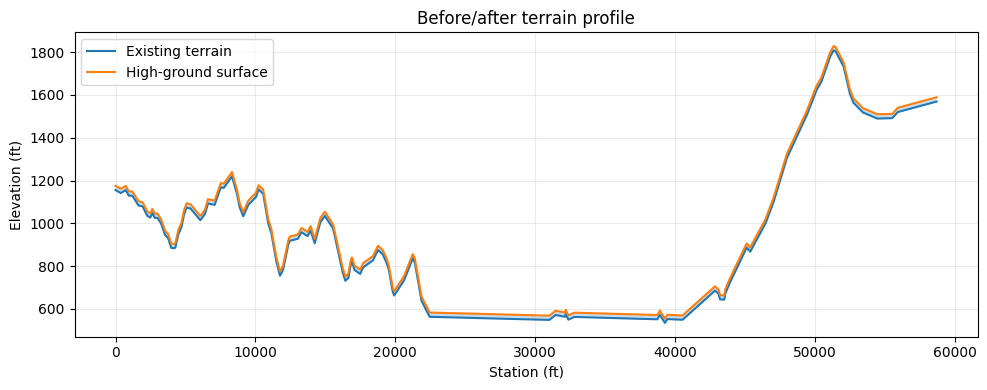

In [4]:
# Before/after terrain profile from the writer-side verification helper
profile_compare = RasTerrainModWriter.apply_modification_to_profile(
    proposed_terrain_hdf,
    'API High Ground Levee',
    baseline_profile,
    x_coords=profile_x,
    y_coords=profile_y,
)
profile_stats = profile_compare['difference'].describe().to_frame('terrain_difference_ft')
display(profile_stats)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile_compare['station'], profile_compare['existing_elevation'], label='Existing terrain')
ax.plot(profile_compare['station'], profile_compare['proposed_elevation'], label='High-ground surface')
ax.fill_between(
    profile_compare['station'],
    profile_compare['existing_elevation'],
    profile_compare['proposed_elevation'],
    where=profile_compare['difference'] > 0,
    alpha=0.25,
)
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('Before/after terrain profile')
ax.legend()
ax.grid(True, alpha=0.25)
profile_png = ARTIFACT_ROOT / 'terrain_profile_difference.png'
fig.tight_layout()
fig.savefig(profile_png, dpi=160)
profile_png

,count,mean,std,min,25%,50%,75%,max
writer_difference,6995.0,19.823576,2.946050,9.803317,17.96446,19.841343,21.443981,29.805717
raster_writer_difference,6995.0,0.000001,0.000011,-0.000066,0.00000,0.000000,0.000000,0.000061


Max writer-vs-raster profile difference: 0.000066 ft


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/terrain_profile_readback_validation.png')

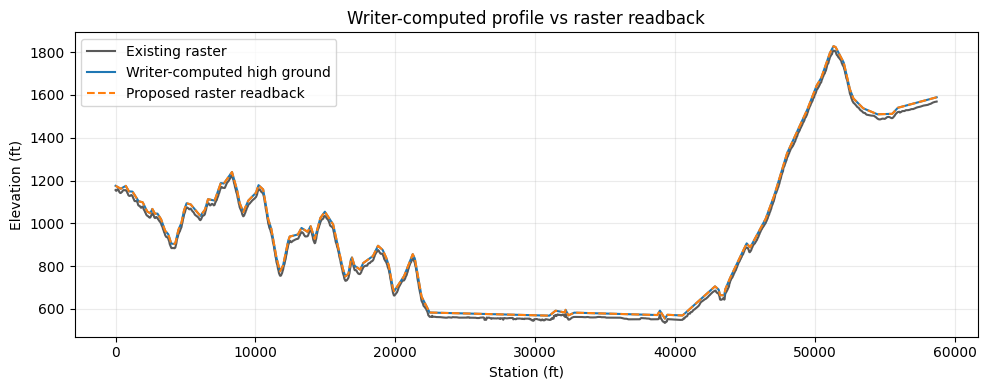

In [5]:
# Read the proposed terrain back through RasMapperLib and compare to writer expectation
readback_filter_tolerance = 0.01
readback_existing = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=readback_filter_tolerance,
)
readback_proposed = RasTerrainMod.get_terrain_profile(
    proposed_project / 'BaldEagleDamBrk.rasmap',
    proposed_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=readback_filter_tolerance,
)
assert not readback_existing.empty, 'Base raster-read terrain profile is empty'
assert not readback_proposed.empty, 'Proposed raster-read terrain profile is empty'

writer_readback_compare = RasTerrainModWriter.apply_modification_to_profile(
    proposed_terrain_hdf,
    'API High Ground Levee',
    readback_existing[['station', 'elevation']],
    x_coords=profile_x,
    y_coords=profile_y,
)
raster_proposed_elevation = np.interp(
    writer_readback_compare['station'].to_numpy(dtype=float),
    readback_proposed['station'].to_numpy(dtype=float),
    readback_proposed['elevation'].to_numpy(dtype=float),
)
readback_validation = writer_readback_compare[[
    'station',
    'x',
    'y',
    'existing_elevation',
    'proposed_elevation',
    'difference',
]].copy()
readback_validation = readback_validation.rename(columns={
    'proposed_elevation': 'writer_proposed_elevation',
    'difference': 'writer_difference',
})
readback_validation['raster_read_elevation'] = raster_proposed_elevation
readback_validation['raster_writer_difference'] = (
    readback_validation['raster_read_elevation']
    - readback_validation['writer_proposed_elevation']
)
readback_max_abs_diff = float(
    readback_validation['raster_writer_difference'].abs().max()
)
readback_tolerance_ft = 0.01
readback_stats = readback_validation[
    ['writer_difference', 'raster_writer_difference']
].describe().T
display(readback_stats)
print(f'Max writer-vs-raster profile difference: {readback_max_abs_diff:.6f} ft')
assert readback_max_abs_diff <= readback_tolerance_ft, (
    f'Raster-read profile differs from writer-computed profile by '
    f'{readback_max_abs_diff:.6f} ft, exceeding {readback_tolerance_ft:.3f} ft'
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    readback_validation['station'],
    readback_validation['existing_elevation'],
    label='Existing raster',
    color='0.35',
)
ax.plot(
    readback_validation['station'],
    readback_validation['writer_proposed_elevation'],
    label='Writer-computed high ground',
    color='tab:blue',
)
ax.plot(
    readback_validation['station'],
    readback_validation['raster_read_elevation'],
    label='Proposed raster readback',
    color='tab:orange',
    linestyle='--',
)
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('Writer-computed profile vs raster readback')
ax.legend()
ax.grid(True, alpha=0.25)
readback_profile_png = ARTIFACT_ROOT / 'terrain_profile_readback_validation.png'
fig.tight_layout()
fig.savefig(readback_profile_png, dpi=160)
readback_profile_png

2026-05-05 17:10:59 - rasterio._env - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: C:\Program Files (x86)\HEC\HEC-RAS\6.6\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


2026-05-05 17:10:59 - rasterio._env - WARNING - CPLE_AppDefined in PROJ: proj_create_from_name: C:\Program Files (x86)\HEC\HEC-RAS\6.6\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


,dataset,count,min_elevation_ft,max_elevation_ft
0,boundary vertices,5,738.21875,1038.40625
1,interior controls,2,925.00000,930.00000
2,profile values,5,738.21875,1038.40625


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/polygon_multipoint_control_points.png')

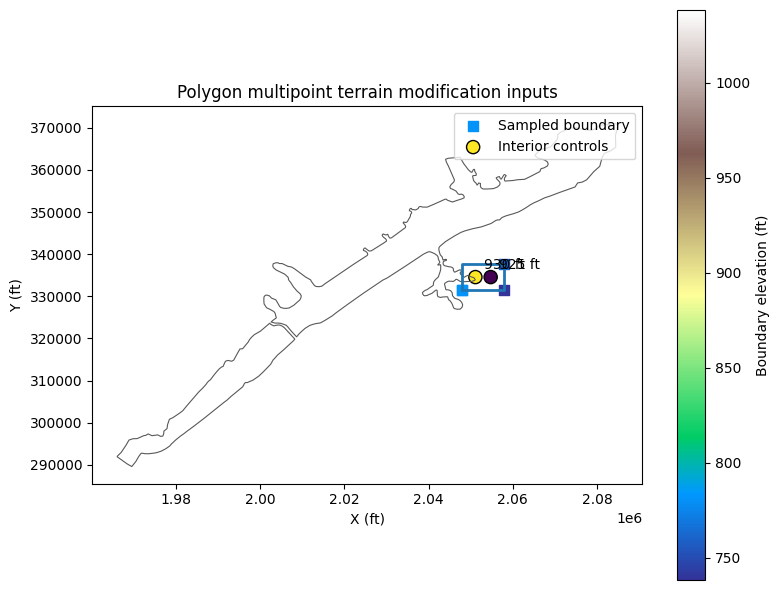

In [6]:
# Polygon multipoint terrain modification writer validation
polygon_name = 'API Multipoint Pond'
poly_cx = minx + 0.62 * (maxx - minx)
poly_cy = miny + 0.28 * (maxy - miny)
poly_w = 0.12 * (maxx - minx)
poly_h = 0.12 * (maxy - miny)
polygon_coords = np.array(
    [
        [poly_cx - 0.5 * poly_w, poly_cy - 0.5 * poly_h],
        [poly_cx + 0.5 * poly_w, poly_cy - 0.5 * poly_h],
        [poly_cx + 0.5 * poly_w, poly_cy + 0.5 * poly_h],
        [poly_cx - 0.5 * poly_w, poly_cy + 0.5 * poly_h],
    ],
    dtype=float,
)
polygon_control_points = [
    {
        'x': poly_cx - 0.18 * poly_w,
        'y': poly_cy,
        'elevation': 930.0,
        'name': 'Pond shelf 930',
    },
    {
        'x': poly_cx + 0.18 * poly_w,
        'y': poly_cy,
        'elevation': 925.0,
        'name': 'Pond bottom 925',
    },
]

RasTerrainModification.add_modification_polygon(
    terrain_hdf_path=polygon_terrain_hdf,
    name=polygon_name,
    polygon_coords=polygon_coords,
    elevation_method='boundary_from_terrain',
    control_points=polygon_control_points,
    rasmap_path=polygon_project / 'BaldEagleDamBrk.rasmap',
    elev_pt_tolerance=15.0,
)

with h5py.File(polygon_terrain_hdf, 'r') as hdf:
    mod = hdf[f'Modifications/{polygon_name}']
    boundary_xyz = mod['Boundary Points'][:]
    control_xyz = mod['Control Points/Elevation Points'][:]
    profile_values = mod['Profile Values'][:]
    polygon_attrs = mod['Attributes'][0]

assert np.all(np.isfinite(boundary_xyz)), 'Boundary elevations must be finite'
np.testing.assert_allclose(control_xyz[:, 2], np.array([930.0, 925.0]))
assert int(polygon_attrs['Generate Boundary Elevations']) == 1
assert int(polygon_attrs['Use ShapeFile Z Elevations']) == 0

root = ET.parse(polygon_project / 'BaldEagleDamBrk.rasmap').getroot()
polygon_layers = [
    layer for layer in root.findall('.//Layer')
    if layer.get('Name') == polygon_name
]
assert len(polygon_layers) == 1
assert polygon_layers[0].get('Type') == 'PolygonElevationModificationLayer'

polygon_summary = pd.DataFrame({
    'dataset': ['boundary vertices', 'interior controls', 'profile values'],
    'count': [len(boundary_xyz), len(control_xyz), len(profile_values)],
    'min_elevation_ft': [
        float(boundary_xyz[:, 2].min()),
        float(control_xyz[:, 2].min()),
        float(profile_values[:, 1].min()),
    ],
    'max_elevation_ft': [
        float(boundary_xyz[:, 2].max()),
        float(control_xyz[:, 2].max()),
        float(profile_values[:, 1].max()),
    ],
})
display(polygon_summary)

fig, ax = plt.subplots(figsize=(8, 6))
mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.35')
closed_polygon = np.vstack([polygon_coords, polygon_coords[0]])
ax.plot(closed_polygon[:, 0], closed_polygon[:, 1], color='tab:blue', linewidth=2.0)
sc_boundary = ax.scatter(
    boundary_xyz[:, 0],
    boundary_xyz[:, 1],
    c=boundary_xyz[:, 2],
    cmap='terrain',
    marker='s',
    s=55,
    label='Sampled boundary',
)
sc_control = ax.scatter(
    control_xyz[:, 0],
    control_xyz[:, 1],
    c=control_xyz[:, 2],
    cmap='viridis',
    marker='o',
    edgecolor='black',
    s=90,
    label='Interior controls',
)
for point, label in zip(control_xyz, ['930 ft', '925 ft']):
    ax.annotate(label, xy=(point[0], point[1]), xytext=(6, 6), textcoords='offset points')
ax.set_aspect('equal')
ax.set_title('Polygon multipoint terrain modification inputs')
ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
ax.legend(loc='upper right')
fig.colorbar(sc_boundary, ax=ax, label='Boundary elevation (ft)')
polygon_points_png = ARTIFACT_ROOT / 'polygon_multipoint_control_points.png'
fig.tight_layout()
fig.savefig(polygon_points_png, dpi=160)
polygon_points_png

,target_x,target_y,target_elevation_ft,readback_station_ft,readback_elevation_ft,readback_minus_target_ft,profile_distance_ft
0,2.051112e+06,334565.04268,930.0,5232.829102,930.0,0.0,0.000132
1,2.054735e+06,334565.04268,925.0,8855.556641,925.0,0.0,0.000076


,count,mean,std,min,25%,50%,75%,max
readback_difference,3.0,186.990756,141.90145,24.46558,137.342856,250.220132,268.253344,286.286556


Control-point writer-vs-raster max abs diff: 0.000000 ft


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/polygon_profile_readback_validation.png')

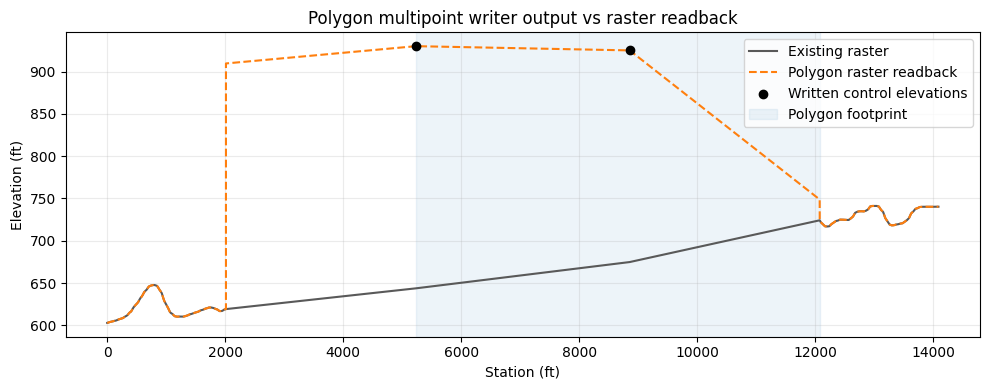

In [7]:
# Read the polygon modification back through RasMapperLib and compare profile response
polygon_profile_x = [poly_cx - 0.70 * poly_w, poly_cx + 0.70 * poly_w]
polygon_profile_y = [poly_cy, poly_cy]
polygon_existing_profile = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    polygon_profile_x,
    polygon_profile_y,
    filter_tolerance=0.01,
)
polygon_readback_profile = RasTerrainMod.get_terrain_profile(
    polygon_project / 'BaldEagleDamBrk.rasmap',
    polygon_geom_hdf,
    polygon_profile_x,
    polygon_profile_y,
    filter_tolerance=0.01,
)
assert not polygon_existing_profile.empty, 'Base polygon profile is empty'
assert not polygon_readback_profile.empty, 'Polygon readback profile is empty'

polygon_stations = polygon_readback_profile['station'].to_numpy(dtype=float)
polygon_existing_interp = np.interp(
    polygon_stations,
    polygon_existing_profile['station'].to_numpy(dtype=float),
    polygon_existing_profile['elevation'].to_numpy(dtype=float),
)
profile_length = float(np.hypot(
    polygon_profile_x[1] - polygon_profile_x[0],
    polygon_profile_y[1] - polygon_profile_y[0],
))
polygon_sample_x = (
    polygon_profile_x[0]
    + (polygon_stations / profile_length)
    * (polygon_profile_x[1] - polygon_profile_x[0])
)
polygon_sample_y = (
    polygon_profile_y[0]
    + (polygon_stations / profile_length)
    * (polygon_profile_y[1] - polygon_profile_y[0])
)
inside_polygon = MplPath(boundary_xyz[:-1, :2]).contains_points(
    np.column_stack([polygon_sample_x, polygon_sample_y]),
    radius=1e-6,
)
polygon_validation = polygon_readback_profile[['station', 'elevation']].copy()
polygon_validation = polygon_validation.rename(columns={'elevation': 'raster_read_elevation'})
polygon_validation['x'] = polygon_sample_x
polygon_validation['y'] = polygon_sample_y
polygon_validation['existing_elevation'] = polygon_existing_interp
polygon_validation['inside_polygon'] = inside_polygon
polygon_validation['readback_difference'] = (
    polygon_validation['raster_read_elevation']
    - polygon_validation['existing_elevation']
)

control_checks = []
for control_point in control_xyz:
    distance = np.hypot(
        polygon_validation['x'].to_numpy(dtype=float) - control_point[0],
        polygon_validation['y'].to_numpy(dtype=float) - control_point[1],
    )
    nearest_idx = int(np.argmin(distance))
    row = polygon_validation.iloc[nearest_idx]
    control_checks.append({
        'target_x': float(control_point[0]),
        'target_y': float(control_point[1]),
        'target_elevation_ft': float(control_point[2]),
        'readback_station_ft': float(row['station']),
        'readback_elevation_ft': float(row['raster_read_elevation']),
        'readback_minus_target_ft': float(row['raster_read_elevation'] - control_point[2]),
        'profile_distance_ft': float(distance[nearest_idx]),
    })
control_check_df = pd.DataFrame(control_checks)
control_max_abs_diff = float(control_check_df['readback_minus_target_ft'].abs().max())
assert control_max_abs_diff <= 0.01, (
    f'Control-point readback differs from written elevations by '
    f'{control_max_abs_diff:.6f} ft'
)
assert polygon_validation.loc[inside_polygon, 'readback_difference'].max() > 200.0

polygon_profile_stats = polygon_validation.loc[
    inside_polygon, ['readback_difference']
].describe().T
display(control_check_df)
display(polygon_profile_stats)
print(f'Control-point writer-vs-raster max abs diff: {control_max_abs_diff:.6f} ft')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    polygon_validation['station'],
    polygon_validation['existing_elevation'],
    label='Existing raster',
    color='0.35',
)
ax.plot(
    polygon_validation['station'],
    polygon_validation['raster_read_elevation'],
    label='Polygon raster readback',
    color='tab:orange',
    linestyle='--',
)
control_station = [
    float(np.hypot(point[0] - polygon_profile_x[0], point[1] - polygon_profile_y[0]))
    for point in control_xyz
]
ax.scatter(
    control_station,
    control_xyz[:, 2],
    color='black',
    zorder=5,
    label='Written control elevations',
)
inside_rows = polygon_validation[polygon_validation['inside_polygon']]
if not inside_rows.empty:
    ax.axvspan(
        inside_rows['station'].min(),
        inside_rows['station'].max(),
        color='tab:blue',
        alpha=0.08,
        label='Polygon footprint',
    )
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('Polygon multipoint writer output vs raster readback')
ax.legend()
ax.grid(True, alpha=0.25)
polygon_profile_png = ARTIFACT_ROOT / 'polygon_profile_readback_validation.png'
fig.tight_layout()
fig.savefig(polygon_profile_png, dpi=160)
polygon_profile_png

,cell_terrain_difference_ft
count,5198.000000
mean,0.169003
std,1.818627
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,20.000000


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/terrain_difference_map.png')

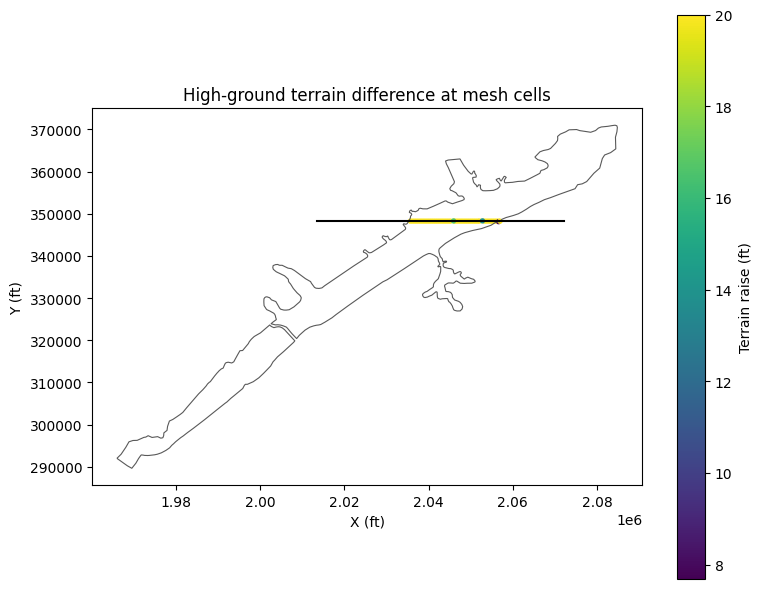

In [8]:
# Terrain difference map at geometry cell-center points
cell_points = HdfMesh.get_mesh_cell_points(base_geom_hdf)
cell_elev = pd.DataFrame({
    'mesh_name': cell_points['mesh_name'],
    'cell_id': cell_points['cell_id'],
    'x': cell_points.geometry.x,
    'y': cell_points.geometry.y,
})
cell_probe = RasTerrainModWriter.sample_modification_surface(
    proposed_terrain_hdf,
    'API High Ground Levee',
    cell_elev[['x', 'y']],
)
cell_existing = np.interp(
    cell_probe['line_station'],
    baseline_profile['station'],
    baseline_profile['elevation'],
)
cell_mod = RasTerrainModWriter.sample_modification_surface(
    proposed_terrain_hdf,
    'API High Ground Levee',
    cell_elev[['x', 'y']],
    existing_elevations=cell_existing,
)
terrain_map = pd.concat(
    [cell_elev[['mesh_name', 'cell_id']], cell_mod],
    axis=1,
)
terrain_map_stats = terrain_map['difference'].describe().to_frame('cell_terrain_difference_ft')
display(terrain_map_stats)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = terrain_map[terrain_map['difference'] > 0.01]
mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.35')
sc = ax.scatter(plot_df['x'], plot_df['y'], c=plot_df['difference'], s=8, cmap='viridis')
ax.plot(profile_x, profile_y, color='black', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title('High-ground terrain difference at mesh cells')
ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
fig.colorbar(sc, ax=ax, label='Terrain raise (ft)')
terrain_png = ARTIFACT_ROOT / 'terrain_difference_map.png'
fig.tight_layout()
fig.savefig(terrain_png, dpi=160)
terrain_png

In [9]:
# Run HEC-RAS base and proposed plans through ras-commander
def force_clean_plan_inputs(project_path):
    for stale in project_path.glob('*.g11.hdf'):
        stale.unlink()
    for stale in project_path.glob('*.c18'):
        stale.unlink()

compute_rows = []
for label, project_path, ras_obj in [
    ('base', base_project, base_ras),
    ('proposed', proposed_project, proposed_ras),
]:
    force_clean_plan_inputs(project_path)
    result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras_obj,
        force_geompre=True,
        force_rerun=True,
        num_cores=2,
        verify=True,
    )
    compute_rows.append({
        'condition': label,
        'success': bool(result),
        'plan_hdf': str(project_path / 'BaldEagleDamBrk.p18.hdf'),
    })
compute_summary = pd.DataFrame(compute_rows)
compute_summary

,condition,success,plan_hdf
0,base,True,H:\Symphony\ras-commander\CLB-279\316_terrain_...
1,proposed,True,H:\Symphony\ras-commander\CLB-279\316_terrain_...


,max_wse_difference_ft
count,5198.000000
mean,0.028338
std,0.088340
min,-0.332947
25%,0.000000
50%,0.000000
75%,0.017456
max,0.806091


Cells with |WSE difference| > 0.01 ft: 1491


WindowsPath('H:/Symphony/ras-commander/CLB-279/316_terrain_modifications/wse_difference_map.png')

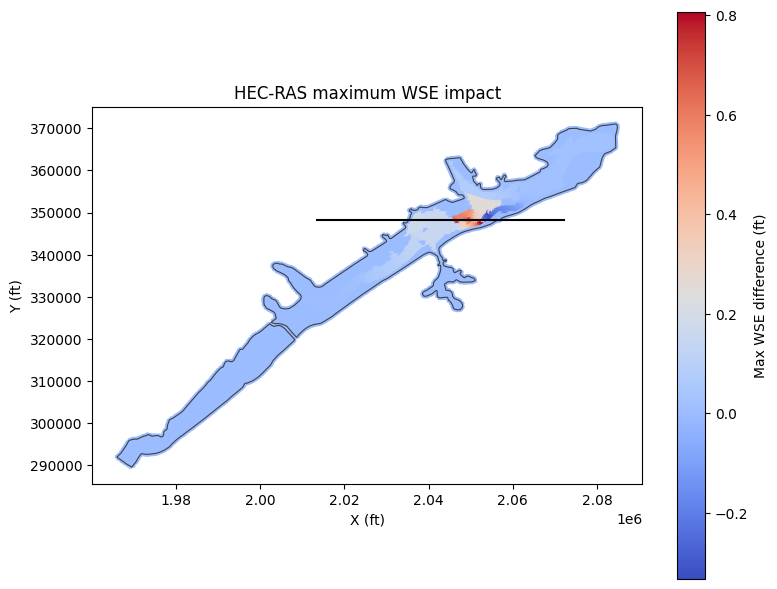

In [10]:
# Compare maximum water surface elevations from result HDF files
base_plan_hdf = base_project / 'BaldEagleDamBrk.p18.hdf'
proposed_plan_hdf = proposed_project / 'BaldEagleDamBrk.p18.hdf'
base_wse = HdfResultsMesh.get_mesh_max_ws(base_plan_hdf)
proposed_wse = HdfResultsMesh.get_mesh_max_ws(proposed_plan_hdf)
wse = base_wse.merge(
    proposed_wse,
    on=['mesh_name', 'cell_id'],
    suffixes=('_base', '_proposed'),
)
wse['wse_difference'] = (
    wse['maximum_water_surface_proposed'] - wse['maximum_water_surface_base']
)
wse_stats = wse['wse_difference'].describe().to_frame('max_wse_difference_ft')
display(wse_stats)
print('Cells with |WSE difference| > 0.01 ft:', int((wse['wse_difference'].abs() > 0.01).sum()))

fig, ax = plt.subplots(figsize=(8, 6))
wse_plot = wse[np.isfinite(wse['wse_difference'])].copy().set_geometry('geometry_base')
wse_plot.plot(
    ax=ax,
    column='wse_difference',
    cmap='coolwarm',
    markersize=7,
    legend=True,
    legend_kwds={'label': 'Max WSE difference (ft)'},
)
mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.25')
ax.plot(profile_x, profile_y, color='black', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title('HEC-RAS maximum WSE impact')
ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
wse_png = ARTIFACT_ROOT / 'wse_difference_map.png'
fig.tight_layout()
fig.savefig(wse_png, dpi=160)
wse_png

In [11]:
# Final artifact list for human review
pd.DataFrame({
    'artifact': [
        'terrain_profile_difference.png',
        'terrain_profile_readback_validation.png',
        'polygon_multipoint_control_points.png',
        'polygon_profile_readback_validation.png',
        'terrain_difference_map.png',
        'wse_difference_map.png',
        'base plan HDF',
        'proposed plan HDF',
    ],
    'path': [
        str(profile_png),
        str(readback_profile_png),
        str(polygon_points_png),
        str(polygon_profile_png),
        str(terrain_png),
        str(wse_png),
        str(base_plan_hdf),
        str(proposed_plan_hdf),
    ],
})

,artifact,path
0,terrain_profile_difference.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
1,terrain_profile_readback_validation.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
2,polygon_multipoint_control_points.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
3,polygon_profile_readback_validation.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
4,terrain_difference_map.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
5,wse_difference_map.png,H:\Symphony\ras-commander\CLB-279\316_terrain_...
6,base plan HDF,H:\Symphony\ras-commander\CLB-279\316_terrain_...
7,proposed plan HDF,H:\Symphony\ras-commander\CLB-279\316_terrain_...
